In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
calendar = pd.read_csv('/kaggle/input/datasets/ssssws/chocolate-sales-dataset-2023-2024/calendar.csv')
customers = pd.read_csv('/kaggle/input/datasets/ssssws/chocolate-sales-dataset-2023-2024/customers.csv')
products = pd.read_csv('/kaggle/input/datasets/ssssws/chocolate-sales-dataset-2023-2024/products.csv')
sales = pd.read_csv('/kaggle/input/datasets/ssssws/chocolate-sales-dataset-2023-2024/sales.csv')
stores = pd.read_csv('/kaggle/input/datasets/ssssws/chocolate-sales-dataset-2023-2024/stores.csv')

In [15]:
# List of dataframes for quick iteration;
dfs = {'Sales': sales, 'Stores': stores, 'Products': products, 'Customers': customers, 'Calendar': calendar}

for name, df in dfs.items():
    print(f'--- {name} Info ---')
    print(df.info())
    print('--' * 30)

--- Sales Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   order_id     1000000 non-null  object 
 1   order_date   1000000 non-null  object 
 2   product_id   1000000 non-null  object 
 3   store_id     1000000 non-null  object 
 4   customer_id  1000000 non-null  object 
 5   quantity     1000000 non-null  int64  
 6   unit_price   1000000 non-null  float64
 7   discount     1000000 non-null  float64
 8   revenue      1000000 non-null  float64
 9   cost         1000000 non-null  float64
 10  profit       1000000 non-null  float64
dtypes: float64(5), int64(1), object(5)
memory usage: 83.9+ MB
None
------------------------------------------------------------
--- Stores Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  

In [16]:
# Data standardization
# Convert order_date in sales
sales['order_date'] = pd.to_datetime(sales['order_date'])

# Convert date in calendar
calendar['date'] = pd.to_datetime(calendar['date'])

# Verifying changes
print(sales['order_date'].dtype)
print(calendar['date'].dtype)

datetime64[ns]
datetime64[ns]


In [17]:
# The Master Merge
# Merge sales with products
df_master = pd.merge(sales, products, on='product_id', how ='left')

# Merge the results with stores
df_master = pd.merge(df_master, stores, on='store_id', how='left')

# Check the new columns
print('New Combined Columns:')
print(df_master.columns.tolist())

df_master.sample(5)

New Combined Columns:
['order_id', 'order_date', 'product_id', 'store_id', 'customer_id', 'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit', 'product_name', 'brand', 'category', 'cocoa_percent', 'weight_g', 'store_name', 'city', 'country', 'store_type']


,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit,product_name,brand,category,cocoa_percent,weight_g,store_name,city,country,store_type
626677,0RD00626678,2023-09-09,P0128,S039,C007224,1,14.86,0.00,14.86,9.79,5.07,White Chocolate 80%,Godiva,Dark,80.0,50.0,Chocolate Store 39,New York,UK,Mall
584992,0RD00584993,2024-08-17,P0038,S009,C048650,5,7.76,0.00,38.80,23.86,14.94,White Chocolate 50%,Cadbury,Milk,50.0,100.0,Chocolate Store 9,Paris,France,Online
952572,0RD00952573,2023-05-19,P0171,S080,C042263,4,8.90,0.15,30.26,19.56,10.70,Dark Chocolate 50%,Mars,Dark,50.0,50.0,Chocolate Store 80,Sydney,Australia,Online
136751,0RD00136752,2023-09-02,P0035,S003,C015696,1,11.56,0.00,11.56,6.34,5.22,White Chocolate 70%,Hershey,Dark,70.0,200.0,Chocolate Store 3,Berlin,France,Mall
691275,0RD00691276,2023-02-09,P0160,S070,C040495,3,7.77,0.20,18.65,12.44,6.21,Praline Chocolate 90%,Hershey,Dark,90.0,100.0,Chocolate Store 70,Toronto,Canada,Online


--- Top 10 Brands by Total Revenue
     brand store_type     revenue
0  Cadbury    Airport  1400595.49
1  Ferrero    Airport  1394302.78
2    Lindt    Airport  1323460.41
3     Mars    Airport  1238874.65
4  Ferrero       Mall  1216791.51
5  Cadbury       Mall  1215238.22
6  Ferrero     Online  1179182.30
7  Cadbury     Online  1169678.07
8    Lindt       Mall  1157521.06
9   Godiva    Airport  1133037.50


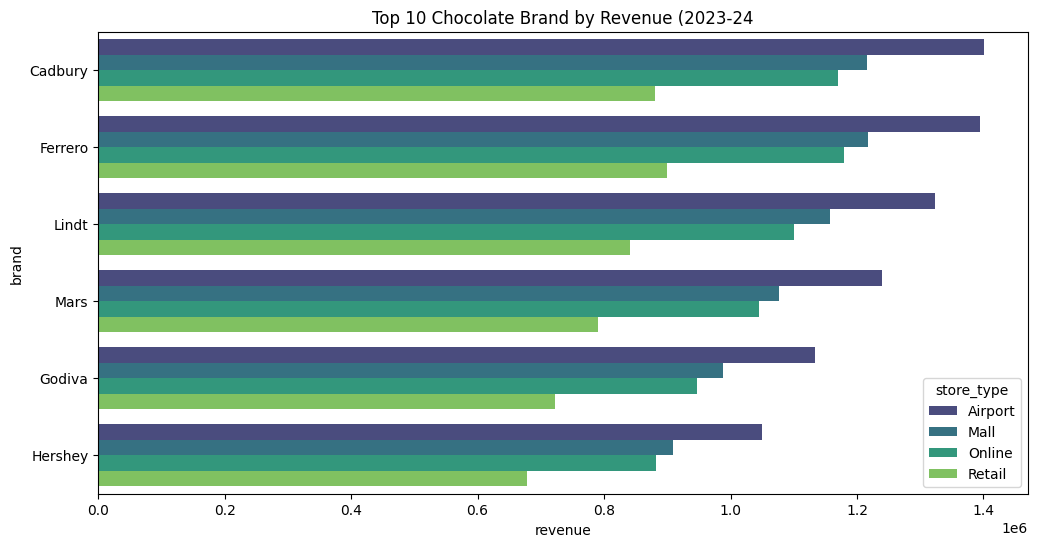

In [18]:
# Sales perfomance analysis
# What is actually making us money?
# Group by Brand and summing the Revenue
brand_performance = df_master.groupby(['brand', 'store_type'])['revenue'].sum().sort_values(ascending=False).reset_index()

# Displaying the Top 10
print('--- Top 10 Brands by Total Revenue')
print(brand_performance.head(10))

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(data=brand_performance, x='revenue', y='brand',hue='store_type', palette='viridis')
plt.title('Top 10 Chocolate Brand by Revenue (2023-24')
plt.show()

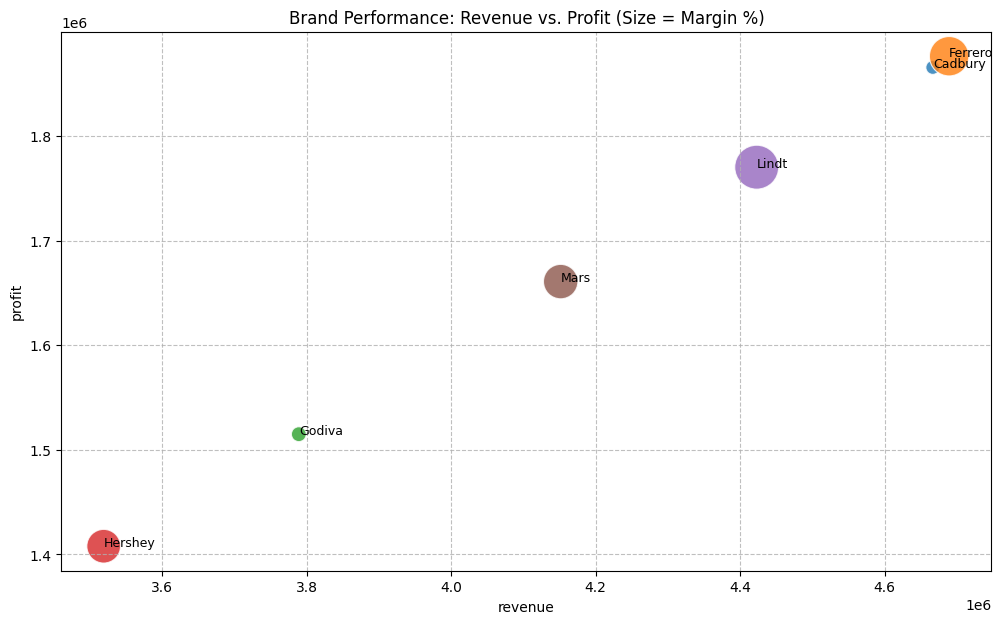

In [19]:
# Efficency & Profitability
# Grouping by Brand to compare total Revenue and total Profit
brand_financials = df_master.groupby('brand').agg({
    'revenue': 'sum',
    'profit': 'sum'
}).reset_index()

# Calculating Profit margin % for deeper insights
brand_financials['profit_margin'] = (brand_financials['profit'] / brand_financials['revenue']) * 100

# Visualization
plt.figure(figsize=(12,7))
sns.scatterplot(data=brand_financials, x='revenue', y='profit', size='profit_margin', hue='brand', sizes=(100,1000),
               legend=False, alpha=0.8)

# Adding labels for the dots
for i in range(brand_financials.shape[0]):
    plt.text(brand_financials.revenue[i], brand_financials.profit[i], brand_financials.brand[i], fontsize=9)

plt.title('Brand Performance: Revenue vs. Profit (Size = Margin %)')
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()

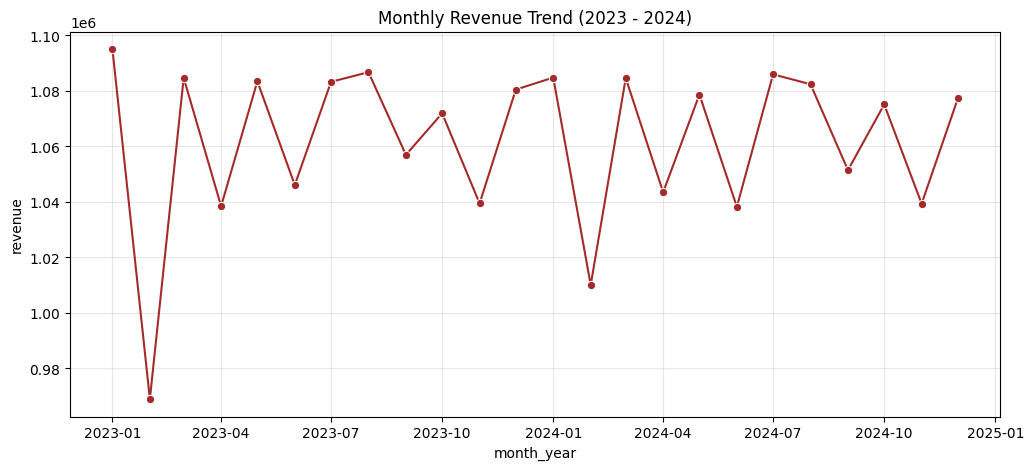

In [20]:
# Time - Series Analysis
df_master['month_year'] = df_master['order_date'].dt.to_period('M')
monthly_sales = df_master.groupby('month_year')['revenue'].sum().reset_index()

# Converting month_year to timestamp
monthly_sales['month_year'] = monthly_sales['month_year'].dt.to_timestamp()

# Plotting trend
plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sales, x='month_year', y='revenue', marker='o', color='brown')
plt.title('Monthly Revenue Trend (2023 - 2024)')
plt.grid(True, alpha=0.3)
plt.show()

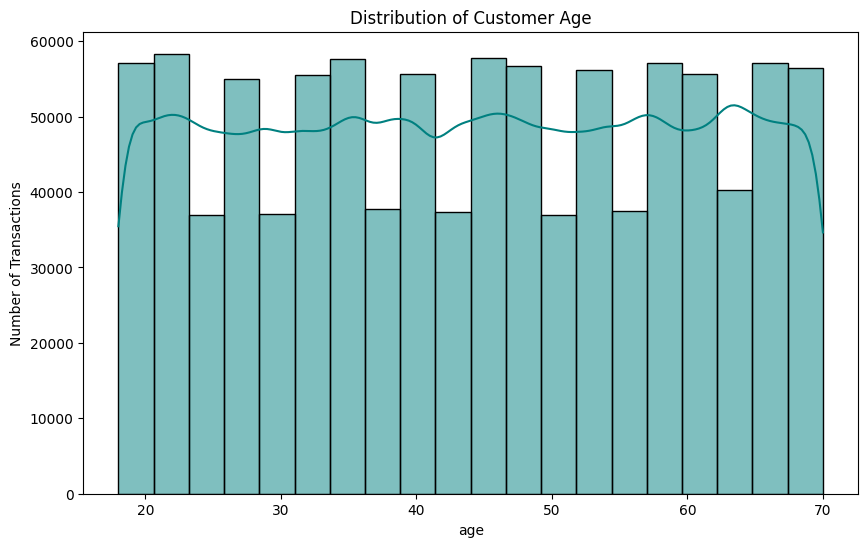

In [21]:
# Distribution Analysis
# Merge customer info in df_master
df_master = pd.merge(df_master, customers, on='customer_id', how='left')

# Plotting the Age Distribution
plt.figure(figsize=(10,6))
sns.histplot(df_master['age'], bins=20, kde=True, color='teal')
plt.title('Distribution of Customer Age')
plt.xlabel('age')
plt.ylabel('Number of Transactions')
plt.show()

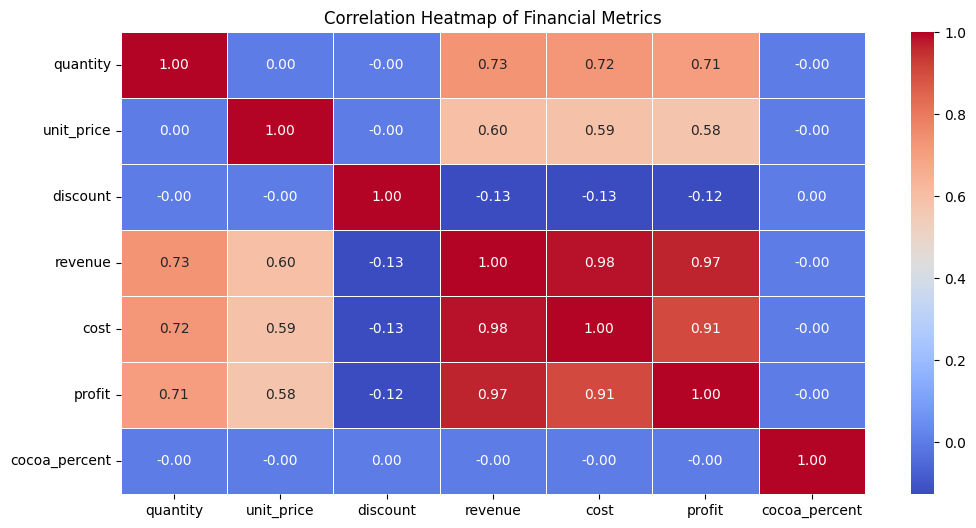

In [22]:
# Relationship Discovery (Correlation Heatmaap)
# Selection of numerical columns
numerical_cols = df_master[['quantity', 'unit_price', 'discount', 'revenue', 'cost',
                            'profit', 'cocoa_percent']]
# Correlation Matrix
corr = numerical_cols.corr()

# Plotting the Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Financial Metrics')
plt.show()

In [23]:
# Final Insights
# Grouping by store type to see avg performance per-location
store_type_comparison = df_master.groupby('store_type').agg({
    'revenue': 'sum',
    'profit': 'sum',
    'quantity': 'sum'
}).reset_index()

# Calculate Profit Margin % for each store type
store_type_comparison['margin_%'] = (store_type_comparison['profit'] / store_type_comparison['revenue']) * 100

print("--- Store Type Performance Summary ---")
print(store_type_comparison.sort_values(by='margin_%', ascending=False))

--- Store Type Performance Summary ---
  store_type     revenue      profit  quantity   margin_%
0    Airport  7613875.92  3046173.74    896417  40.008187
3     Retail  4857988.51  1943309.37    571561  40.002346
2     Online  6386035.76  2554237.38    751100  39.997230
1       Mall  6628228.67  2650844.14    780511  39.993251


**Chocolate Sales Analysis Report: 2023 -- 2024 (synthetic data)**
------------------------------------------------

This report summarizes the key findings from an Exploratory Data Analysis (EDA) of 1 million synthetic retail transactions. The goal of this analysis was to identify top-performing brands, locations, and consumer trends to guide future business strategy.

* * * * *

### **1\. Executive Summary**

The chocolate business maintains a stable, high-margin performance across all channels. While **Ferrero** and **Cadbury** lead in total volume, the **Airport** store segment emerges as the most critical driver of both revenue and profitability. The customer base is remarkably diverse, showing no specific age bias.

* * * * *

### **2\. Sales & Profitability Performance**

#### **Top Performing Brands**

The market is led by two "Power Brands," while smaller players maintain high efficiency.

-   **Volume Leaders:** **Ferrero** and **Cadbury** are the top revenue generators, acting as the primary anchors for retail traffic.

-   **Efficiency Leaders:** **Lindt** and **Hershey** maintain high **Profit Margins**, proving that a "premium" or "specialized" positioning allows for strong USD returns even with lower sales volume.

#### **Store Type Comparison**

Our analysis of store formats revealed that travel-based retail is the most lucrative.

| **Store Type** | **Total Revenue (USD)** | **Total Profit (USD)** | **Profit Margin (%)** |
| --- | --- | --- | --- |
| **Airport** | **7,613,875.92** | **3,046,173.74** | **40.01%** |
| **Mall** | 6,628,228.67 | 2,650,844.14 | 39.99% |
| **Online** | 6,386,035.76 | 2,554,237.38 | 39.99% |
| **Retail** | 4,857,988.51 | 1,943,309.37 | 40.00% |

* * * * *

### **3\. Consumer & Market Trends**

#### **Demographic Insights**

The data shows a **Uniform Distribution** of customer ages (18--70).

-   **Insight:** Chocolate is a universal product. Marketing efforts do not need to be segmented by age, as all cohorts purchase at nearly identical rates.

#### **Seasonality & Stability**

The **Monthly Revenue Trend** shows a consistent "zigzag" pattern rather than extreme seasonal spikes.

-   **Insight:** The business enjoys **stable, year-round demand**. Unlike traditional retailers who rely heavily on a "Golden Month," this model shows resilience across all quarters.

#### **Price Sensitivity**

There is a **Negative Correlation (-0.13)** between **Discounts** and **Quantity Sold**.

-   **Insight:** Customers are not buying significantly more just because a product is on sale. This suggests that chocolate is an "impulse" or "habitual" purchase where price is not the primary driver.

* * * * *

### **4\. Strategic Recommendations**

-   **Prioritize Airport Expansion:** Direct future capital investment toward **Airport** locations, as they yield the highest absolute profit and volume.

-   **Review Discounting Strategy:** Reduce deep discounting on "Power Brands" (Ferrero/Cadbury). Since discounts don't drive volume, maintaining the full list price will directly increase the bottom line in USD.

-   **Unified Marketing:** Utilize a broad-reach marketing strategy. Since the age distribution is flat, focus on **brand lifestyle** and **gifting** rather than age-specific demographics.